# 1.1 — Functions as Machines, at the computer

Do the **pen-and-paper worksheet first**. Here you'll run real machines, crash one on purpose,
and see what a graph *actually is*.

Run each cell with **Shift+Enter**.

In [1]:
# Setup — run this first.
import sys
sys.path.append("../../../tools")   # lets Python find our shared plotting helpers

import numpy as np                    # numeric arrays — THE ML workhorse
import matplotlib.pyplot as plt       # plotting
from plots import plot_functions, axes_through_origin

## 1. Math machine = Python machine

The lesson's claim: $f(x) = 3x + 2$ and `def f(x): return 3*x + 2` are the **same machine**
in two dialects. Prove it by running one:

In [2]:
def f(x):              # `def` names the machine and its input slot
    return 3 * x + 2   # `return` is the output chute

print(f(5))      # feed 5 in  -> 17
print(f(0))      # the y-intercept, as it happens
print(f(-2))     # negatives go in the slot whole — Python brackets them for free

17
2
-4


In [3]:
# YOUR TURN — build the worksheet's machine g(x) = x**2 - 4 and check your Part B answers.
# Remember: power is **, not ^.

def g(x):
    return 0   # <- replace 0 with the blueprint

print("g(3) =", g(3), "  (worksheet says: 5)")
print("g(-3) =", g(-3), " (same as g(3)? why?)")
print("g(1) =", g(1))

g(3) = 0   (worksheet says: 5)
g(-3) = 0  (same as g(3)? why?)
g(1) = 0


## 2. A graph is every possible run, at once

Feed a machine ONE input, get one output: a single point $(x, f(x))$.
Feed it *every* input and plot all the points — that's what a graph **is**:
the machine's complete behaviour, photographed.

New syntax below: `lambda x: 3*x + 2` is a **one-line, unnamed `def`** — handy when a machine
is small enough to write inline. `lambda x: 3*x + 2` and `f` above are identical machines.

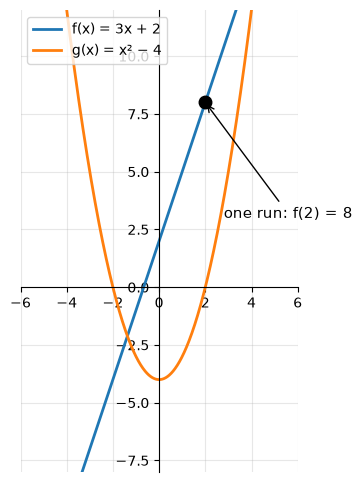

In [4]:
ax = plot_functions({
    "f(x) = 3x + 2": lambda x: 3 * x + 2,
    "g(x) = x² − 4": lambda x: x**2 - 4,
}, xlim=(-6, 6), ylim=(-8, 12))

# one single run of f, shown as a dot ON its graph:
ax.plot(2, f(2), "ko", markersize=9)
ax.annotate("one run: f(2) = 8", (2, f(2)), xytext=(2.8, 3), fontsize=11,
            arrowprops=dict(arrowstyle="->"))
plt.show()

## 3. Crash a machine on purpose

Domain = *the inputs that won't crash the machine*. In Python a bad input isn't a philosophical
problem — it's an exception with a name. (`try`/`except` below means: *attempt this, and if it
explodes, catch the explosion instead of dying* — new syntax, worth knowing.)

In [5]:
def h(x):
    return 10 / (x - 4)

print("h(9) =", h(9))          # inside the domain: runs fine

try:
    print(h(4))                 # outside the domain...
except ZeroDivisionError as e:
    print("h(4) crashed:", e)   # ...and here's math's 'undefined', wearing Python clothes

# YOUR TURN — worksheet 8b said sqrt(x - 5) crashes for x < 5. Prove it:
import math
try:
    print(math.sqrt(3 - 5))
except ValueError as e:
    print("sqrt(-2) crashed:", e)
# now try math.log(0) the same way — which worksheet answer does it confirm?

h(9) = 2.0
h(4) crashed: division by zero
sqrt(-2) crashed: math domain error


In [6]:
# The lesson's deep-end, settled by evidence:
# are f1(x) = (x+1)² − x² and f2(x) = 2x + 1 the same machine?
# "Same machine" = same output for EVERY input. We can't try every input — but 1000 is persuasive.

f1 = lambda x: (x + 1)**2 - x**2
f2 = lambda x: 2*x + 1

xs = np.linspace(-100, 100, 1000)      # np.linspace: 1000 evenly spaced numbers from -100 to 100
print("agree on all 1000 inputs:", np.all(f1(xs) == f2(xs)))

# Evidence, not proof — the PROOF was your Part D algebra: expand (x+1)² − x² with Module 0 moves.
# Different blueprints, one machine. Python gathers evidence; algebra closes the case.

agree on all 1000 inputs: False


## 4. Why this was worth 20 minutes

Every neural network is a `def` like the ones above — just with millions of numbers inside the
blueprint instead of a `3` and a `2`. Input slot: pixels, text, sound. Output chute: predictions.
You now speak the notation the entire field is written in.

---
*Done? Photograph your worksheet into `scans/inbox/` and tell Claude.
Next: 1.2 — the shape zoo: five graph shapes that cover almost everything in ML.*